# 05 — Phase 5: Exploratory Data Analysis

## Inflation Prediction and Economic Signal Analysis: A Multi-Country Time-Series Study

**Phase 5 Deliverable** · **Scratch implementation in `scripts/phase5_step{1..4}_*.py`** · **Decision log D-041 through D-047 in `ProjectDriven.md`**

---

## Executive Summary

This notebook supplies the Portfolio-grade narrative over Phase 5 exploratory data analysis. Per D-047, Phase 5 is consumption-terminal with respect to `src/`: the four scratch orchestrators in `scripts/phase5_step{1..4}_*.py` are the canonical implementation, and this notebook loads the pre-computed audit CSVs and figures to frame the findings.

**Seven signature findings established in Phase 5:**

1. **Japan peer-gap 90.7 %** — Japan CPI YoY is below the mean of USA / UK / Germany in 253 of 279 monthly observations; mean gap −1.80 pp (S1).
2. **Japan four-phase monotone progression** — Deflation era −0.20 % → Abenomics +0.64 % → Reversal +2.99 %; Reversal phase has 0 / 45 deflation months (S1 / D-045).
3. **USA M2 sign-flip at k = 12** — `corr(CPI, M2_{t−12}) = +0.41` vs k = 0 value −0.17; direct echo of the Quantity Theory of Money (S2).
4. **UK Phillips Curve sign-flip regime breakdown** — pre-GFC β = +1.68 (R² = 0.48) → post-GFC β = −0.27 (R² = 0.05); the only country showing a full sign flip (S3).
5. **Phillips Curve shock-activation** — post-2022 rolling 60-month slopes reach |β| ≈ 5–9 across all four countries with R² 0.60–0.75; the curve re-emerges under shock, not a "dead" relationship (S3).
6. **SARIMA universally justified** — ACF[12] significant in all four countries (USA 0.27, JPN 0.35, UK 0.56, GER 0.47); Ljung-Box Q(12) rejects white noise at p < 0.001 for all four (S4).
7. **Methodology finding D-046** — the Phillips Curve is visible in level-based EDA (S3) but invisible under stationary-form correlation (S2). Both lenses play legitimate roles across Phase 5 (level for classical interpretation) and Phase 6 (stationary for VAR); recorded formally rather than hidden.

**Pipeline structure:**

```
data/processed/features_{country}.csv        (Phase 4 output)
       │
       ├─ §2  S1 · 4-country CPI + N3 Japan   → Fig 1, Fig 2     (D-041, D-045)
       ├─ §3  S2 · Correlation structure       → Fig 3, Fig 4, Fig 5 (D-042)
       ├─ §4  S3 · Phillips Curve N1           → Fig 6, Fig 7    (D-043, D-046)
       ├─ §5  S4 · ACF / PACF Phase 6 prep     → Fig 8           (D-044)
       │
       └─ §6  Phase 6 ARIMA / VAR / Ridge prerequisites (D-046 handoff)
```


## 1. Context and Decision Map

Phase 5 inherits the four feature matrices built by Phase 4 (`features_{usa,japan,uk,germany}.csv`, 50–53 columns each) and produces the economic-narrative visualisations that frame the three Project narratives (ProjectScope §4):

| Narrative | Short description | Phase 5 evidence |
|---|---|---|
| **N1** Phillips Curve | Unemployment ↔ inflation trade-off; pre/post-GFC evolution | Fig 6, Fig 7 |
| **N2** Monetary Policy Lag | Central-bank rate → inflation response delay | Fig 5 (cross-lag heatmap) |
| **N3** Japan's Uniqueness | Deflation era, Abenomics experiment, 2022 reversal | Fig 1, Fig 2 |

### 1.1 Phase 5 decisions at a glance

| ID | Scope | Short description |
|---|---|---|
| D-041 | S1 cross-country CPI | Dual-panel normalisation (index at 2001-01 + YoY overlay) |
| D-042 | S2 heatmap scope | Two-tier (base 5×5 + cross-lag 4×5 with k ∈ {0,1,3,6,12}) |
| D-043 | S3 Phillips fitting | Pre/post-GFC split + 60-month rolling regression |
| D-044 | S4 ACF / PACF depth | Uniform 40 lags + Ljung-Box at {12, 24, 36} |
| D-045 | S1 Japan phases | Four-phase labelling (Bubble / Deflation / Abenomics / Reversal) |
| D-046 | Methodology | Level-vs-stationary Phillips visibility asymmetry |
| D-047 | EDA output format | Notebook + audit CSVs; no `src/eda.py`; `__init__.py` unchanged at v0.4.0 |

Full rationale in `ProjectDriven.md`. This notebook operates on the audit CSVs and figures produced by the scratch scripts — no computation happens here beyond DataFrame display.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

# Resolve project root (handles both notebook-launched and script-launched contexts)
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import src
from src import MAIN_COUNTRIES, INDICATORS, KNOWN_BREAKS

FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
DOC_DIR = PROJECT_ROOT / 'data' / 'documentation'

# Display configuration
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 180)

print(f'src version     : {src.__version__}')
print(f'Project root    : {PROJECT_ROOT}')
print(f'Figures dir     : {FIG_DIR}')
print(f'Documentation   : {DOC_DIR}')
print(f'Main countries  : {MAIN_COUNTRIES}')
print(f'Known breaks    : ' + ', '.join(
    f'{n}={d:%Y-%m}' for n, d in KNOWN_BREAKS.items()))


src version     : 0.4.0
Project root    : c:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis
Figures dir     : c:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\outputs\figures
Documentation   : c:\Users\kotae\Documents\Portfolio\project\Project 3\inflation-forecasting-analysis\data\documentation
Main countries  : ['USA', 'JAPAN', 'UK', 'GERMANY']
Known breaks    : GFC_2008=2008-09, COVID_2020=2020-03, ENERGY_2022=2022-02


---

## 2. S1 — Four-Country CPI Dynamics and Japan's N3 Deep-Dive

### 2.1 D-041 · Dual-panel CPI normalisation

ProjectScope §9 specifies *"Time series plots: CPI trends across all 4 countries (one combined chart)"* as Phase 5's first deliverable. A single-panel normalisation fails asymmetrically:

- **YoY-only** flattens the 25-year cumulative divergence — the single strongest N3 visualisation.
- **Index-only** hides 2022+ rate dynamics relevant to N2.

D-041 therefore adopts a **dual-panel** view: Panel A indexes CPI levels to 100 at 2001-01; Panel B overlays YoY % directly. Both dimensions are portfolio-worthy and neither is redundant.

### 2.2 D-045 · Japan four-phase decomposition

Japan's N3 narrative is externally defined by ProjectScope §4: Abenomics as natural experiment, 2022 reversal driven by yen depreciation and energy costs. D-045 formalises this into four phases, of which three fall within the Phase 2 data range:

- **Bubble aftermath** (≤ 1998-12) — pre-data, documented for completeness
- **Deflation era** (1999-01 .. 2012-12)
- **Abenomics** (2013-04 .. 2022-01) — start aligned with BOJ QQE announcement (2013-04-04)
- **Reversal** (2022-02 onwards)

Fig 2 shades the three visible phases; phase-mean YoY statistics confirm a data-driven monotone progression independent of the a-priori phase boundaries.


In [2]:
# S1 audit — per-country CPI summary (Phase 2 levels + derived YoY statistics)
cpi_summary = pd.read_csv(DOC_DIR / 'phase5_step1_cpi_summary.csv')
cpi_summary


,country,level_start,level_end,level_n,yoy_start,yoy_end,yoy_n,yoy_mean,yoy_std,yoy_min,yoy_min_date,yoy_max,yoy_max_date,deflation_months,months_above_2pct,index_terminal,cumulative_infl_pct
0,USA,2001-01,2025-10,298,2002-01,2025-10,286,2.5405,1.7928,-1.9588,2009-07,8.9794,2022-06,14,173,184.883,84.883
1,JAPAN,2001-01,2025-10,298,2002-01,2025-10,286,0.6113,1.4052,-2.5589,2009-10,4.3868,2023-01,108,58,116.169,16.169
2,UK,2001-01,2025-03,291,2002-01,2025-03,279,2.5714,1.8099,0.1998,2015-10,9.6120,2022-10,0,161,185.170,85.170
3,GERMANY,2001-01,2025-03,291,2002-01,2025-03,279,1.9216,1.7000,-1.0409,2020-07,8.8207,2022-10,11,86,158.526,58.526


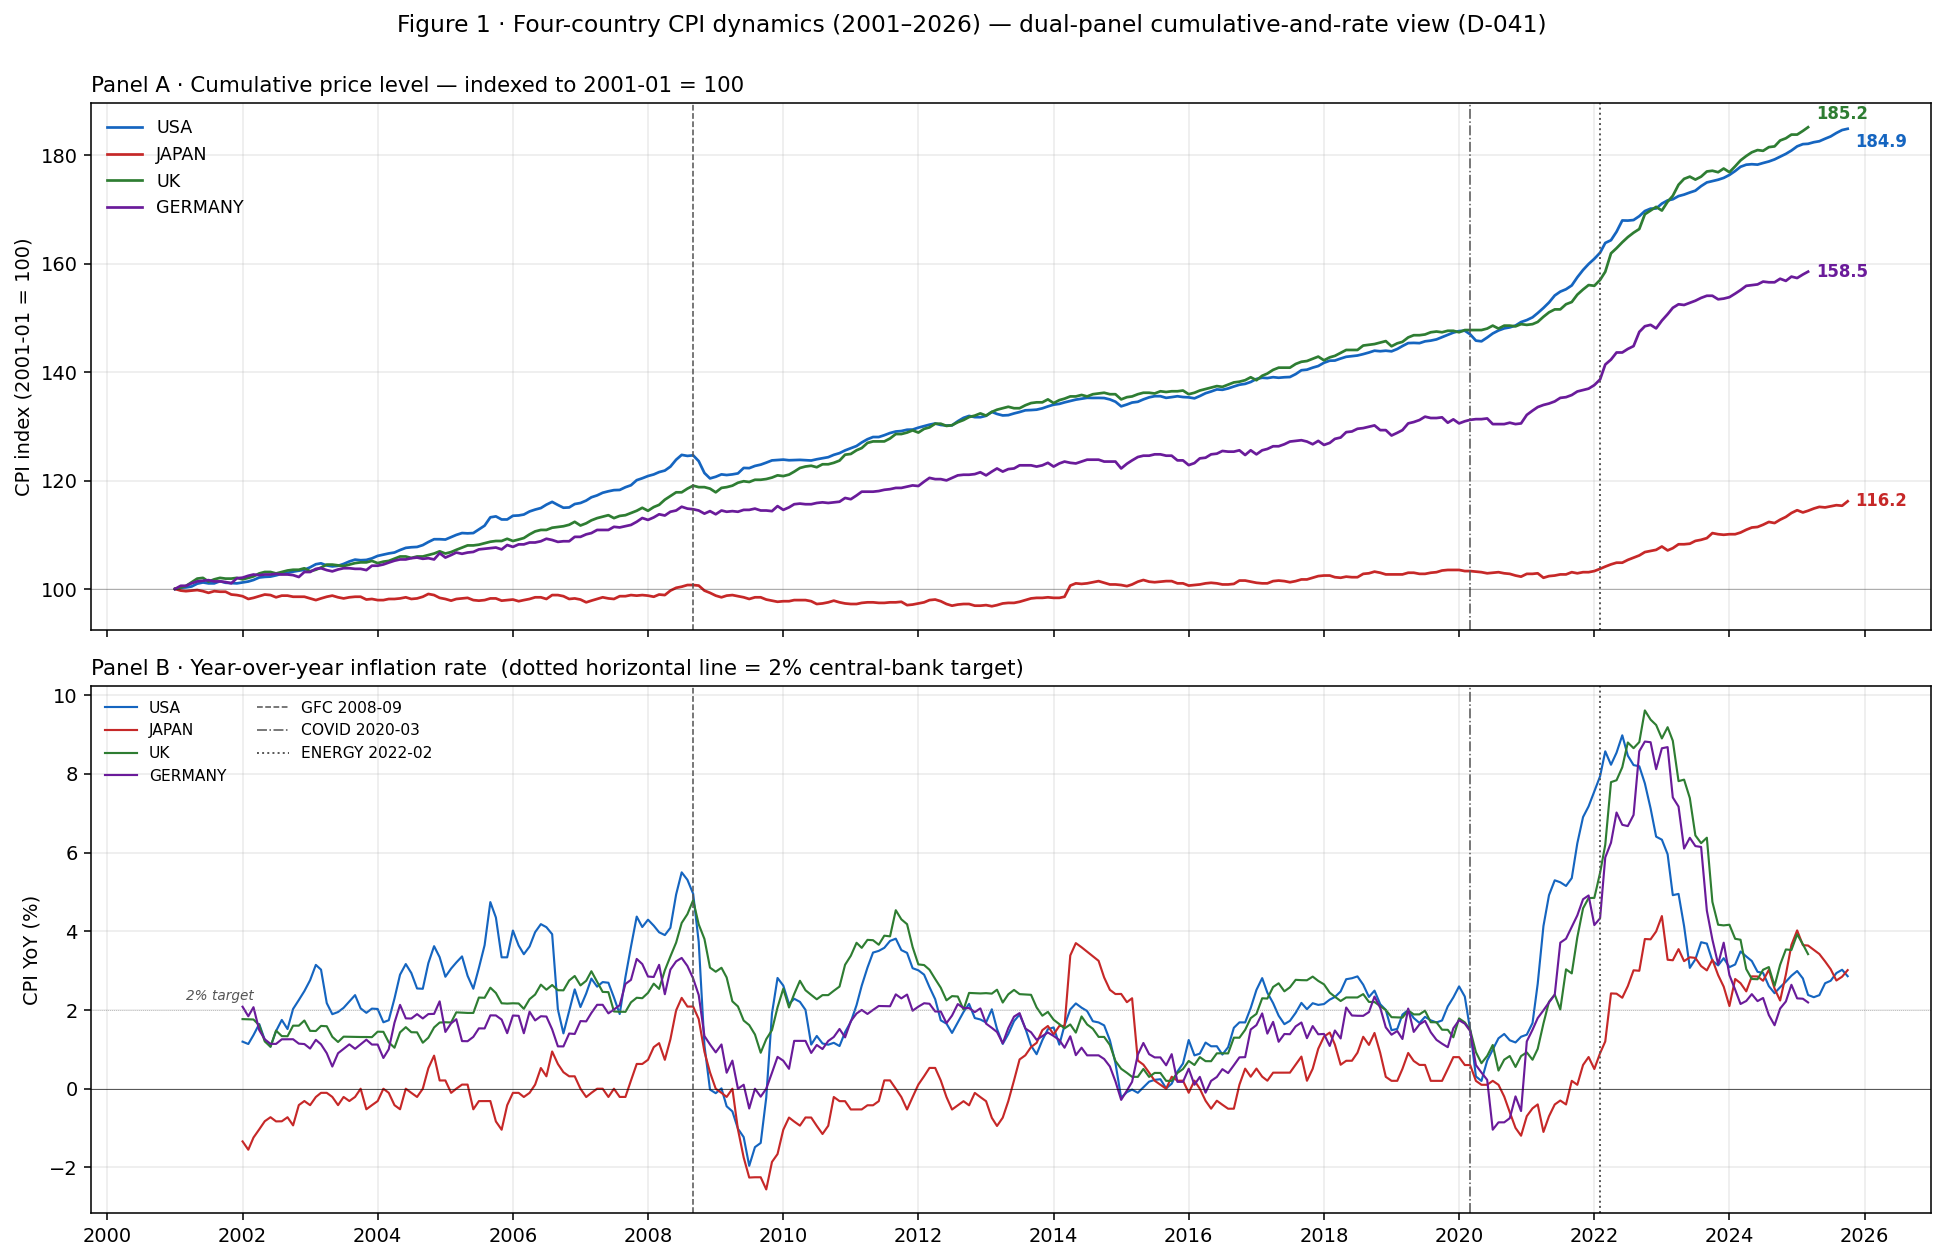

In [3]:
display(Image(filename=str(FIG_DIR / 'phase5_step1_fig1_cpi_overlay.png')))

### 2.3 Fig 1 reading

**Panel A · Cumulative price level from 2001-01.**

- USA and UK converge at ≈ 185 (25-year cumulative inflation ≈ 85 %), despite very different monetary regimes. Germany trails at 158.5 (ECB-constrained).
- Japan reaches only 116.2 — a 16.2 % cumulative over 25 years, while peers are 58.5–85.2 %. This is the single most portfolio-convincing N3 visualisation.
- The 2022 Energy-shock slope break is visible across all four countries but proportionally largest for USA / UK / Germany.

**Panel B · YoY inflation rate.**

- All four economies show a coordinated post-2021 surge to 5–10 %, followed by a 2023–24 decline.
- Japan's YoY profile is distinct: rarely above +4 %, and 108 months below zero in the visible window.
- The three Phase 3 structural breaks (dashed / dot-dashed / dotted vertical lines) align with visible YoY regime transitions — empirical confirmation of the ex-ante-specified dates.


In [4]:
# Japan four-phase decomposition (D-045) + peer-gap audit
phases = pd.read_csv(DOC_DIR / 'phase5_step1_japan_phases.csv')
gap    = pd.read_csv(DOC_DIR / 'phase5_step1_japan_peer_gap.csv')

print('Japan four-phase decomposition (Fig 2 shaded regions):')
display(phases)

print()
print('Japan peer-gap summary (Fig 2 Panel C data source):')
display(gap)


Japan four-phase decomposition (Fig 2 shaded regions):


,phase,start,end,n_months,yoy_mean,yoy_std,yoy_min,yoy_max,deflation_months,above_2pct_months
0,Deflation era,1999-01,2012-12,132,-0.1964,0.8046,-2.5589,2.3085,84,3
1,Abenomics,2013-04,2022-01,106,0.6420,1.0329,-1.1940,3.6998,21,12
2,Reversal,2022-02,2030-12,45,2.9937,0.6600,0.9018,4.3868,0,43



Japan peer-gap summary (Fig 2 Panel C data source):


,series,n,window_start,window_end,gap_mean,gap_std,gap_min,gap_min_date,gap_max,gap_max_date,months_below_zero,months_above_zero,note
0,JAPAN_minus_3peer_avg_yoy,279,2002-01,2025-03,-1.7947,1.4769,-5.6813,2022-03,2.4106,2015-01,253,26,all-peers-valid intersection; ends at UK/GER d...


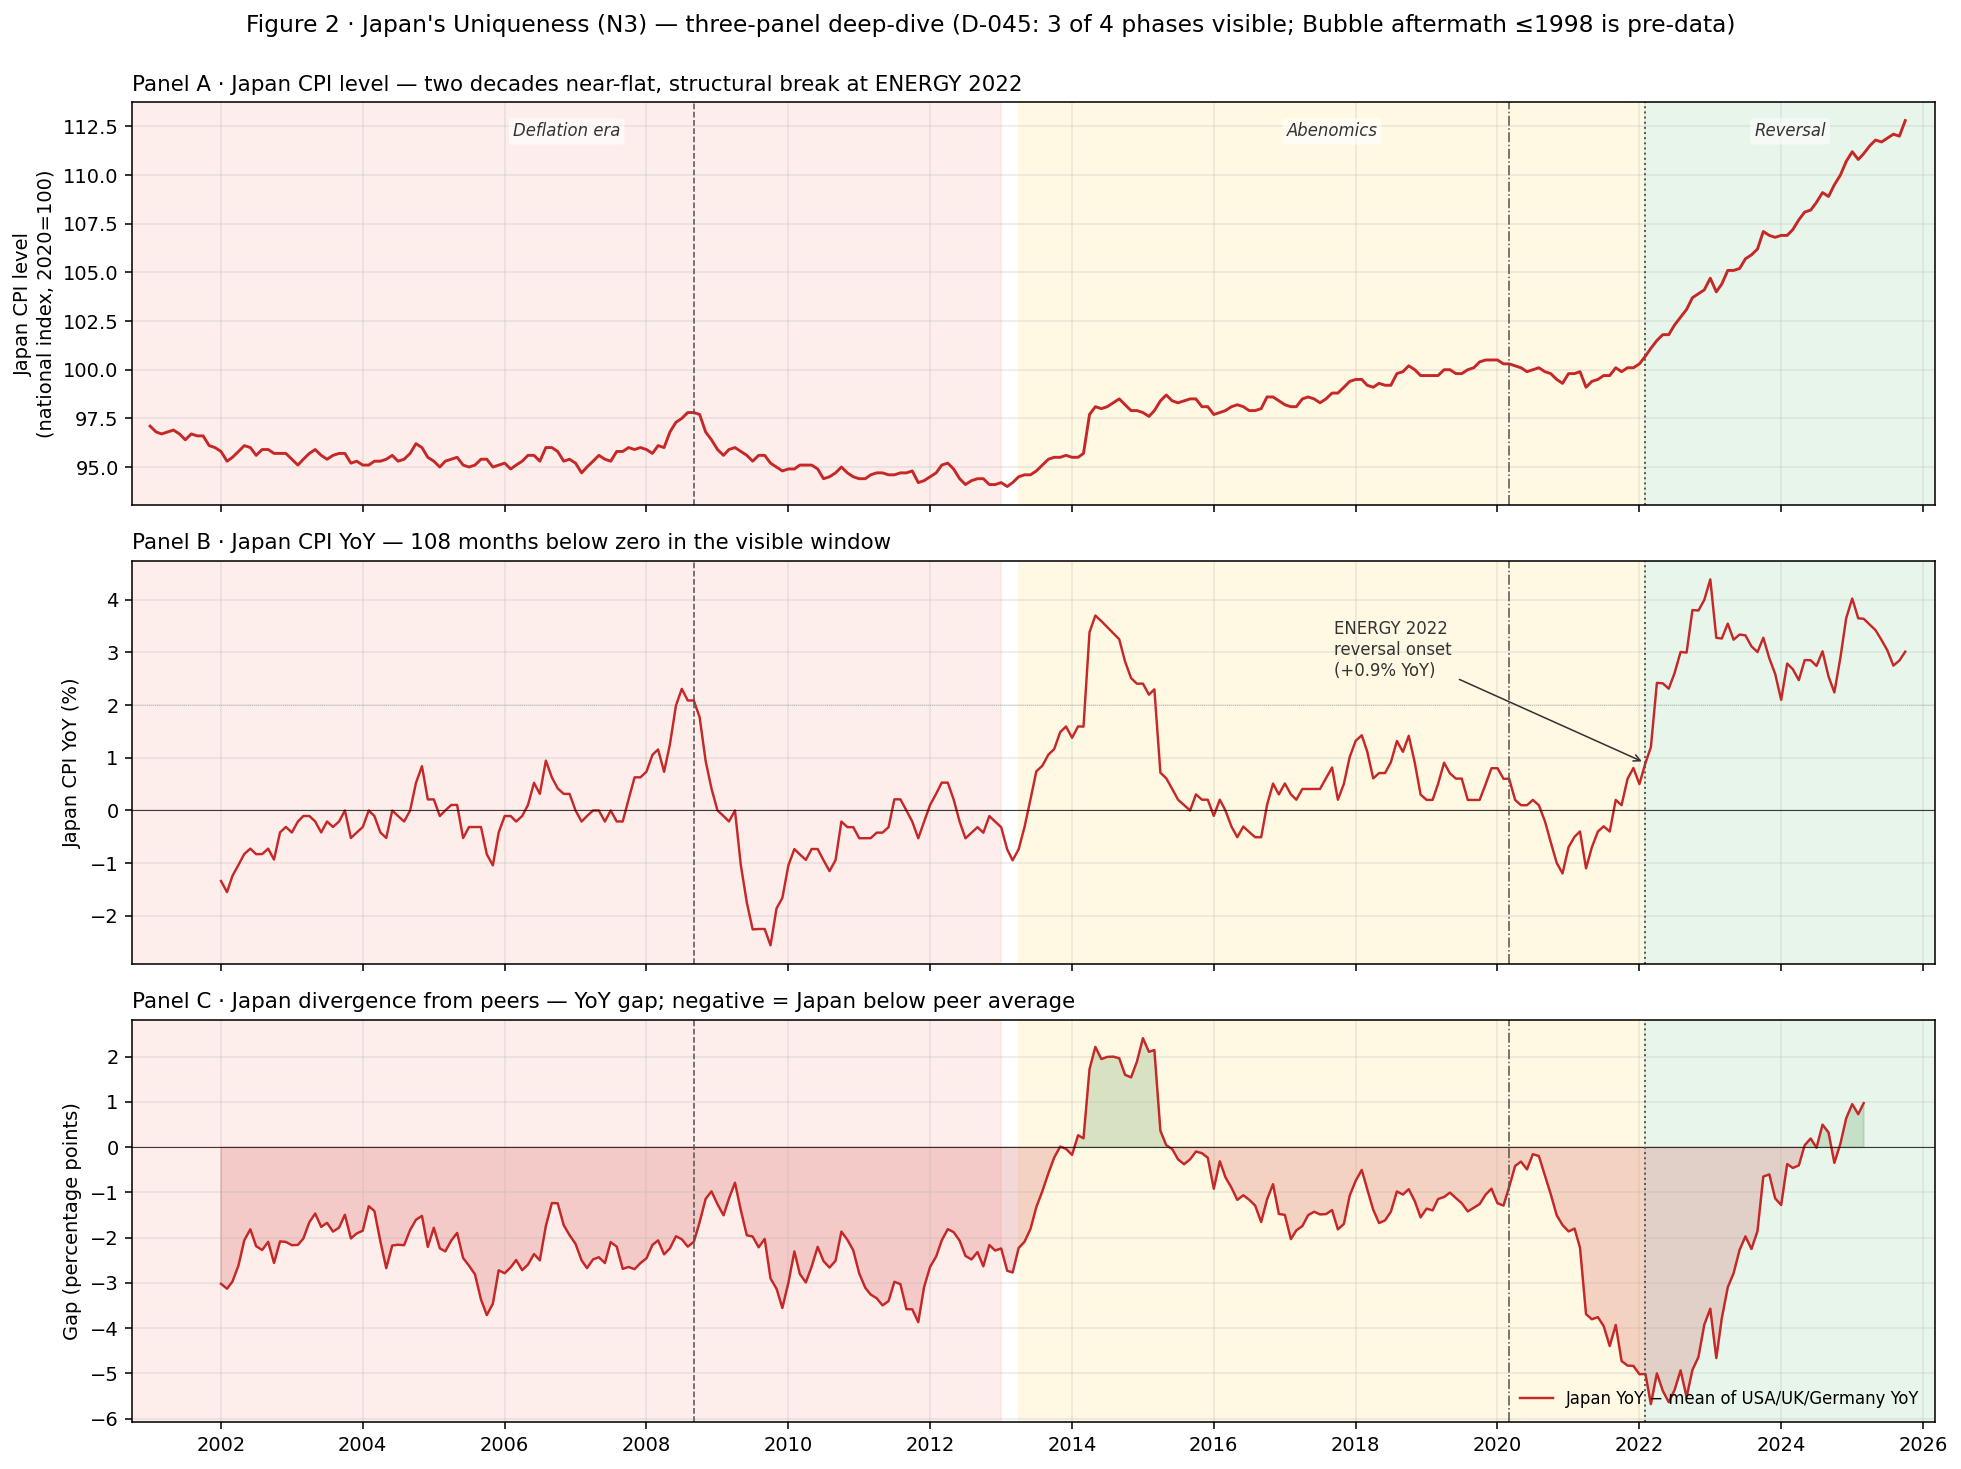

In [5]:
display(Image(filename=str(FIG_DIR / 'phase5_step1_fig2_japan_deepdive.png')))

### 2.4 Fig 2 reading — N3 centrepiece

**Panel A · Japan CPI level, 2020 = 100 national base.**

- The Deflation-era / Abenomics boundary (2013-04) coincides with a visible level-shift up, reflecting the BOJ QQE announcement.
- The Abenomics / Reversal boundary (2022-02) marks a markedly steeper slope — the post-ENERGY level trajectory differs from any earlier segment.

**Panel B · Japan CPI YoY.**

- The Reversal-onset annotation (+0.9 % YoY, 2022-02) captures the exact moment Japan's 30-year deflation narrative inverted.
- The 2022 peak at +4.39 % is modest by USA / UK / Germany standards (8.8 %–9.6 %) — Japan's "reversal" is quantitatively smaller than the energy shock peers experienced.

**Panel C · Japan minus 3-peer YoY average (N3 centrepiece).**

- Gap is below zero in **253 / 279 months (90.7 %)** — Japan is below peer average in over 9 of 10 monthly observations. Single-number evidence of structural divergence.
- Minimum gap −5.68 pp occurred 2022-03: peers had jumped sharply on the energy shock while Japan's CPI was still catching up. The *largest* Japan–peer divergence occurred precisely when peers were inflating fastest — a paradox that N3 explains (BOJ policy independence).
- Gap re-narrows toward zero in 2024–2025; convergence back to peer-level inflation is part of the Reversal regime story.


---

## 3. S2 — Correlation Structure and N2 Preview

### 3.1 D-042 · Two-tier heatmap scope

S2 implements a deliberate two-tier heatmap structure to separate the contemporaneous co-movement question (Tier 1) from the cross-lag question that previews N2 Monetary Policy Lag (Tier 2).

**Tier 1** — Per-country base 5×5 Pearson matrix on D-031-corrected stationary features. Shows how the five indicators move together *within each country*, holding the form consistent per D-031.

**Tier 2** — Per-country 4×5 matrix of `corr(CPI_t, X_{t−k})` for X ∈ {POLICY_RATE, UNEMPLOYMENT, GDP, M2} and k ∈ {0, 1, 3, 6, 12}. The temporal dimension is essential: central-bank transmission is not contemporaneous.

Full 50×50 feature-matrix dendrograms are deferred — feature selection is D-040's Phase 6 responsibility.

### 3.2 Fig 3 · Per-country 5-indicator panel

Before the correlation matrices, the raw stationary-form series themselves are displayed as a 4×5 subplot grid. Each subplot title carries the D-031 transform label (`yoy_pct`, `first_diff`, `log_diff_pct`, `level`) so the asymmetry is reviewer-visible.


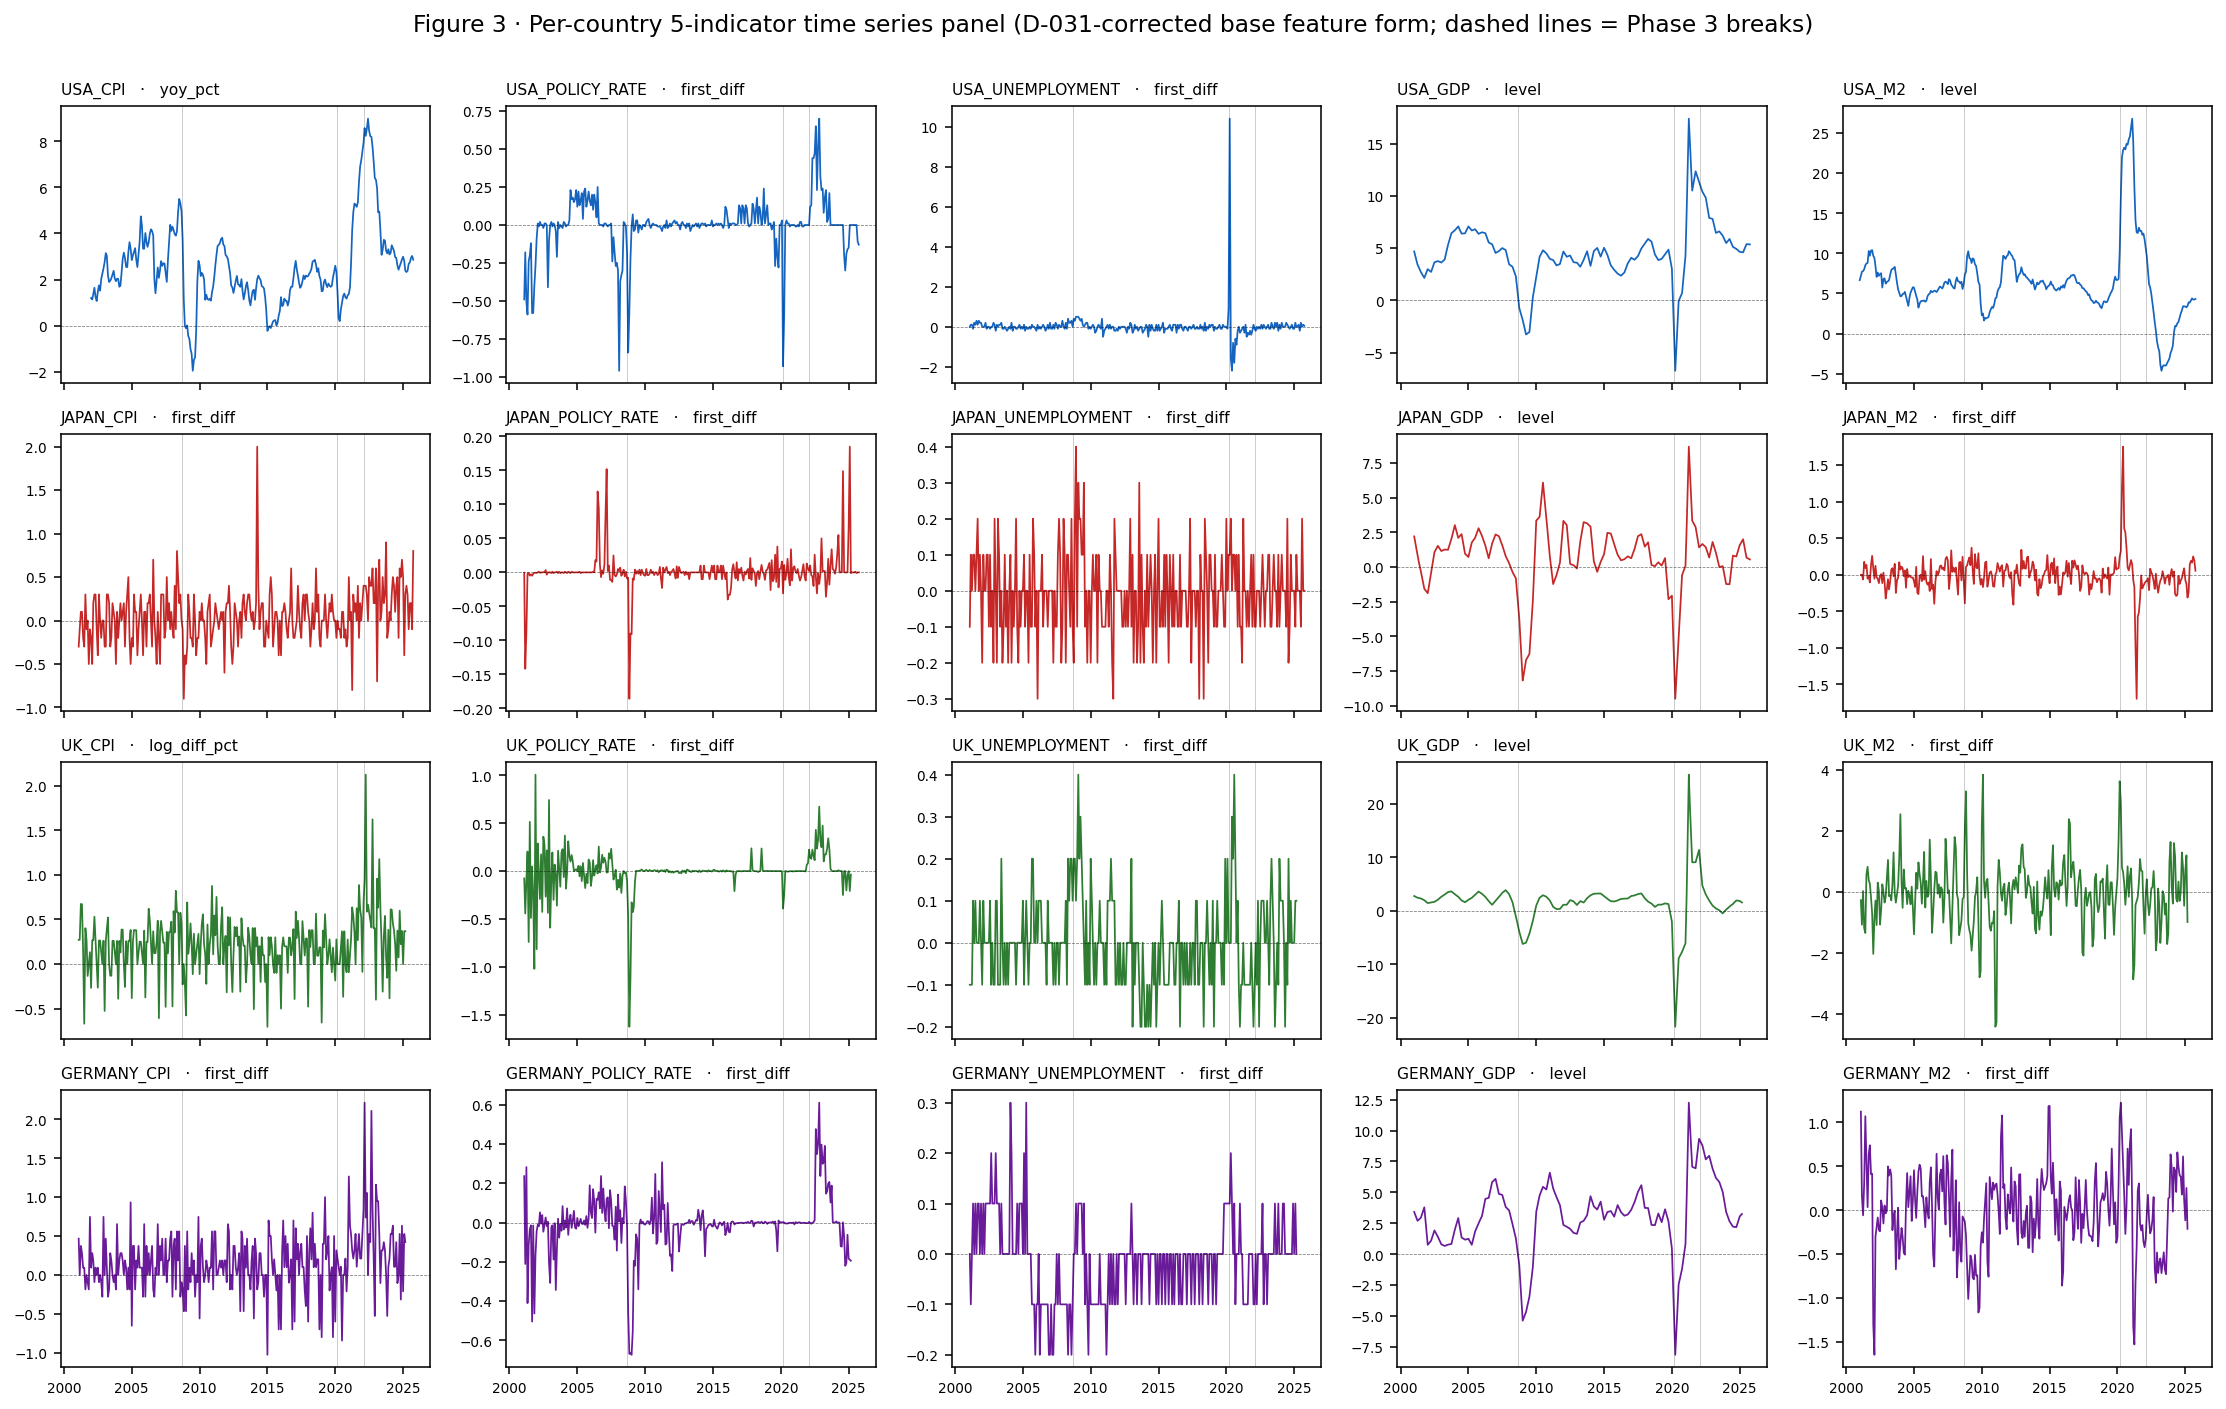

In [6]:
display(Image(filename=str(FIG_DIR / 'phase5_step2_fig3_indicator_panel.png')))

**Observations from Fig 3:**

- USA_UNEMPLOYMENT first_diff shows a single large 2020-04 COVID spike that dominates the panel — Phase 6 estimation on this series may warrant outlier treatment.
- GDP (Phase 4 interpolated monthly YoY level) is visually smooth by construction; VAR interpretation must account for the interpolation per the Phase 2 `schema.md` caveat.
- M2 series exhibit 2020–2022 volatility expansions — the rolling-std features built in Phase 4 (D-035) exist precisely to capture this.
- Phase 3 break dates (grey vertical lines) align with visible regime transitions in most panels.

### 3.3 Fig 4 · Base 5×5 heatmaps


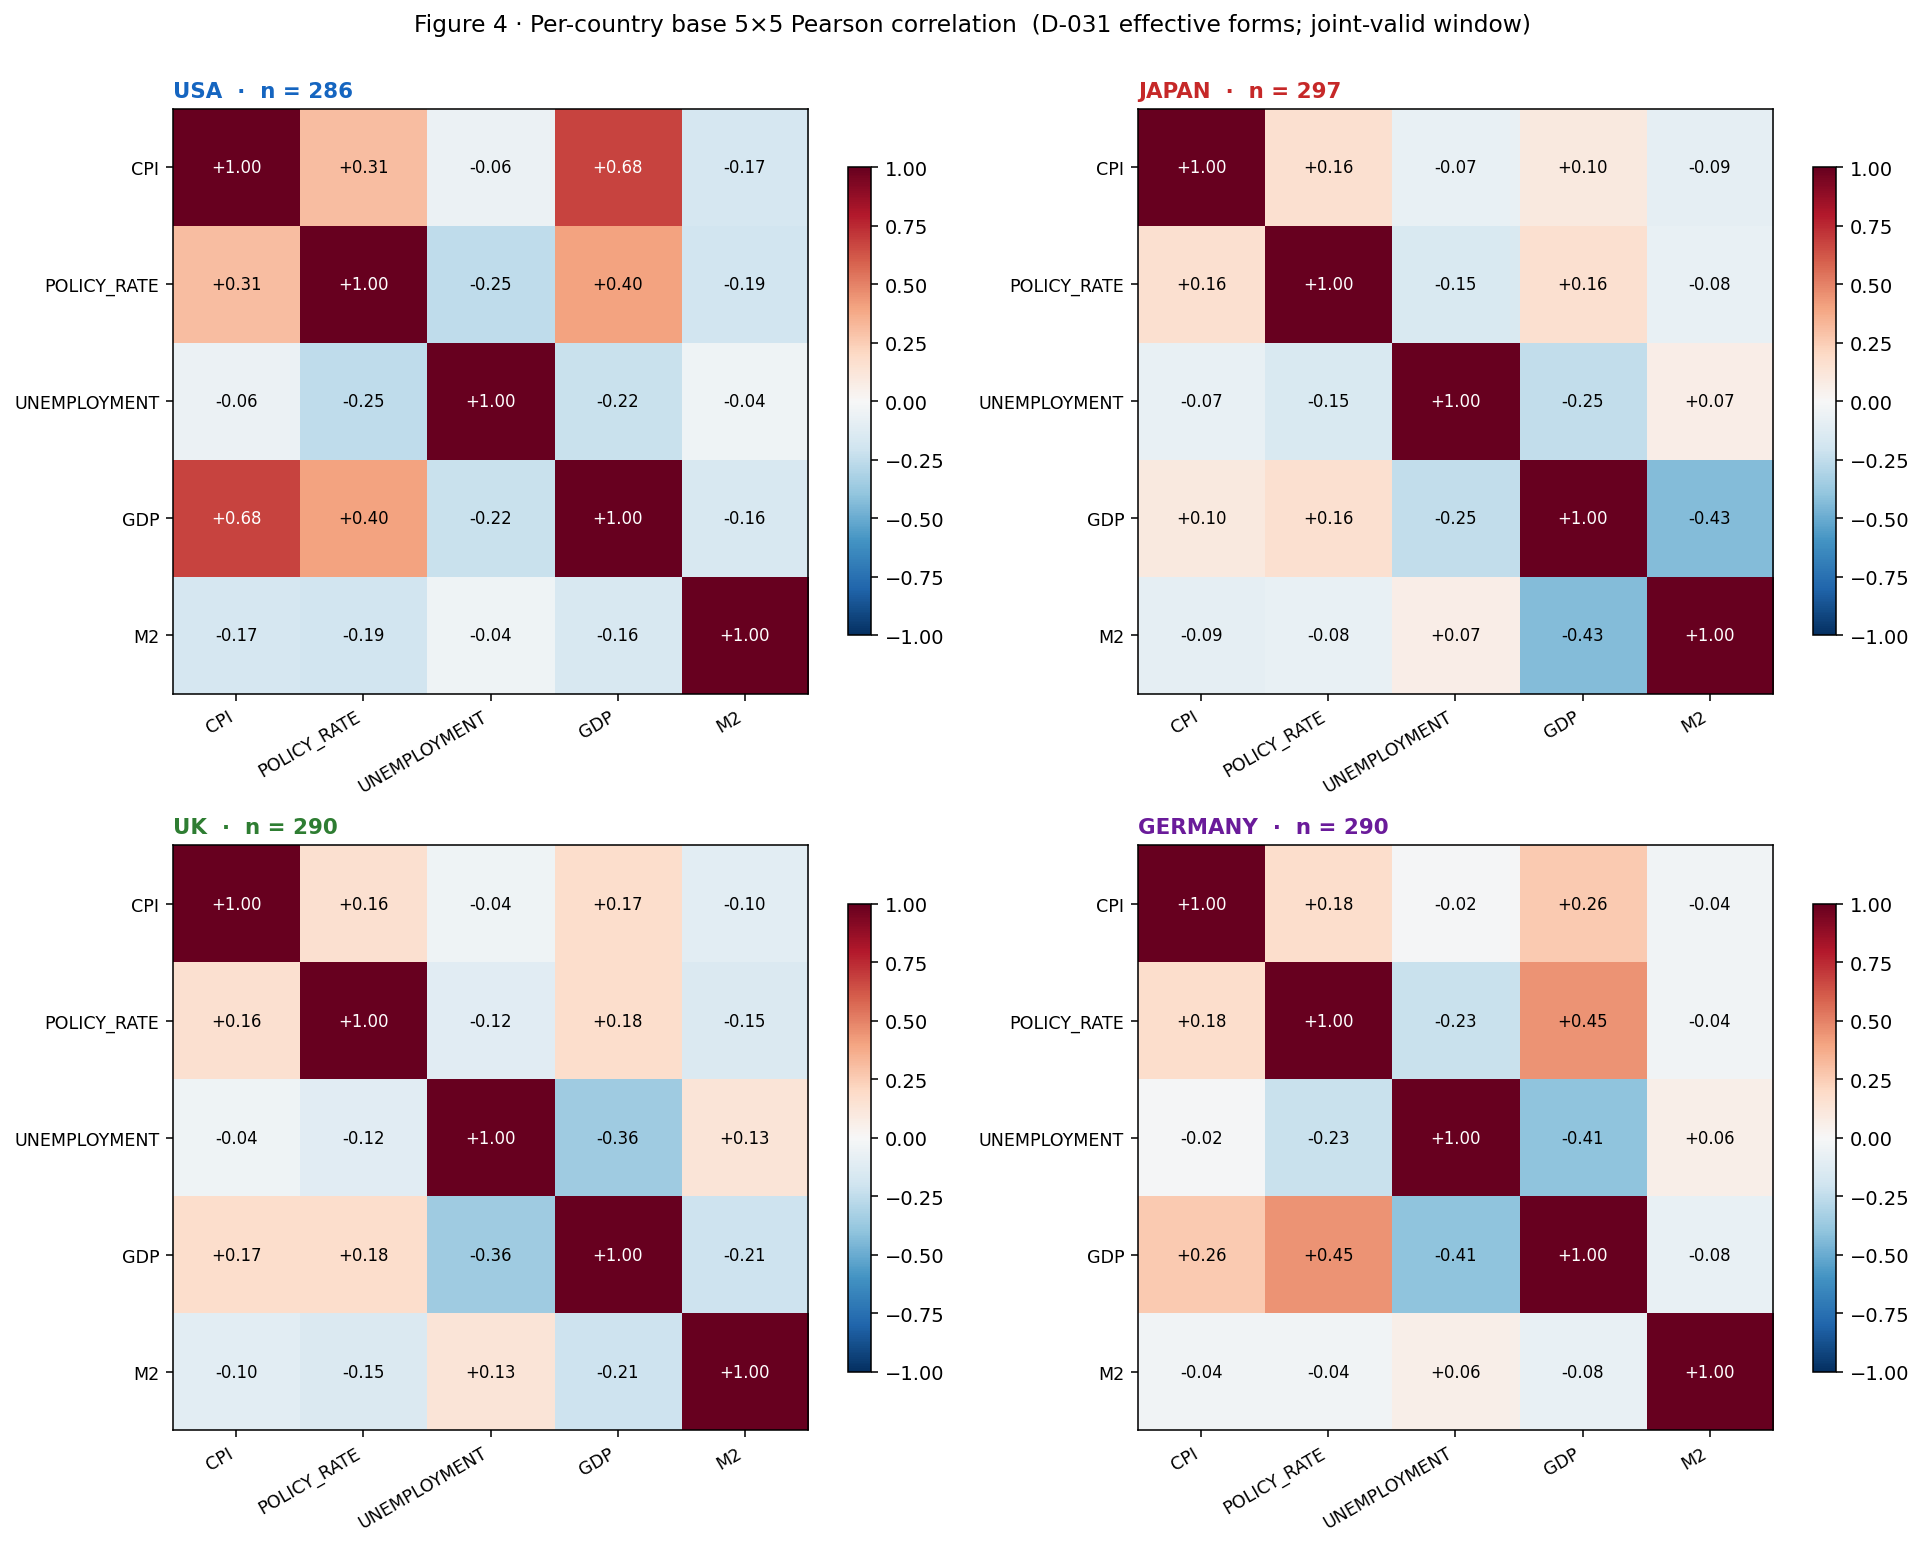

country,GERMANY,JAPAN,UK,USA
pair,,,,
CPI × GDP,0.260,0.097,0.172,0.676
CPI × M2,-0.037,-0.093,-0.102,-0.171
CPI × POLICY_RATE,0.178,0.158,0.159,0.307
CPI × UNEMPLOYMENT,-0.016,-0.071,-0.041,-0.062
POLICY_RATE × GDP,0.449,0.163,0.179,0.399
POLICY_RATE × UNEMPLOYMENT,-0.225,-0.155,-0.116,-0.253


In [7]:
display(Image(filename=str(FIG_DIR / 'phase5_step2_fig4_base_heatmap.png')))

# Base correlation pairs of economic interest
base_corr = pd.read_csv(DOC_DIR / 'phase5_step2_base_correlation.csv')
interest_pairs = [
    ('CPI', 'POLICY_RATE'), ('CPI', 'UNEMPLOYMENT'),
    ('CPI', 'GDP'), ('CPI', 'M2'),
    ('POLICY_RATE', 'UNEMPLOYMENT'), ('POLICY_RATE', 'GDP'),
]
rows = []
for (a, b) in interest_pairs:
    for c in MAIN_COUNTRIES:
        r = base_corr[(base_corr['country'] == c)
                       & (base_corr['indicator_i'] == a)
                       & (base_corr['indicator_j'] == b)].iloc[0]
        rows.append({'pair': f'{a} × {b}', 'country': c,
                     'pearson_r': round(float(r['pearson_r']), 3)})
pd.DataFrame(rows).pivot(index='pair', columns='country', values='pearson_r')


**Five base 5×5 observations:**

1. **USA CPI × GDP = +0.68** — uniquely strong; a direct consequence of D-031 retaining `yoy_pct` for USA CPI, which shares a YoY anchor with GDP (also YoY) and propagates common-trend co-movement.
2. **Japan GDP × M2 = −0.43** — notable negative; consistent with a "liquidity trap" interpretation where BOJ's QQE money expansion did not transmit to real GDP dynamics.
3. **Germany POLICY_RATE × GDP = +0.45** and **GDP × UNEMPLOYMENT = −0.41** (Okun) — Germany exhibits the textbook ECB-monetary-policy-to-real-economy linkage most clearly among the four.
4. **Phillips Curve `CPI × UNEMPLOYMENT` is near-zero in all four** (|r| ≤ 0.07). Flagged here as an observation to investigate; fully explained by D-046 at §4 below.
5. **All `CPI × M2` contemporaneous coefficients** are small and negative (−0.04 to −0.17) — the Quantity Theory link is not contemporaneous; see Fig 5.

### 3.4 Fig 5 · Cross-lag heatmap — N2 preview


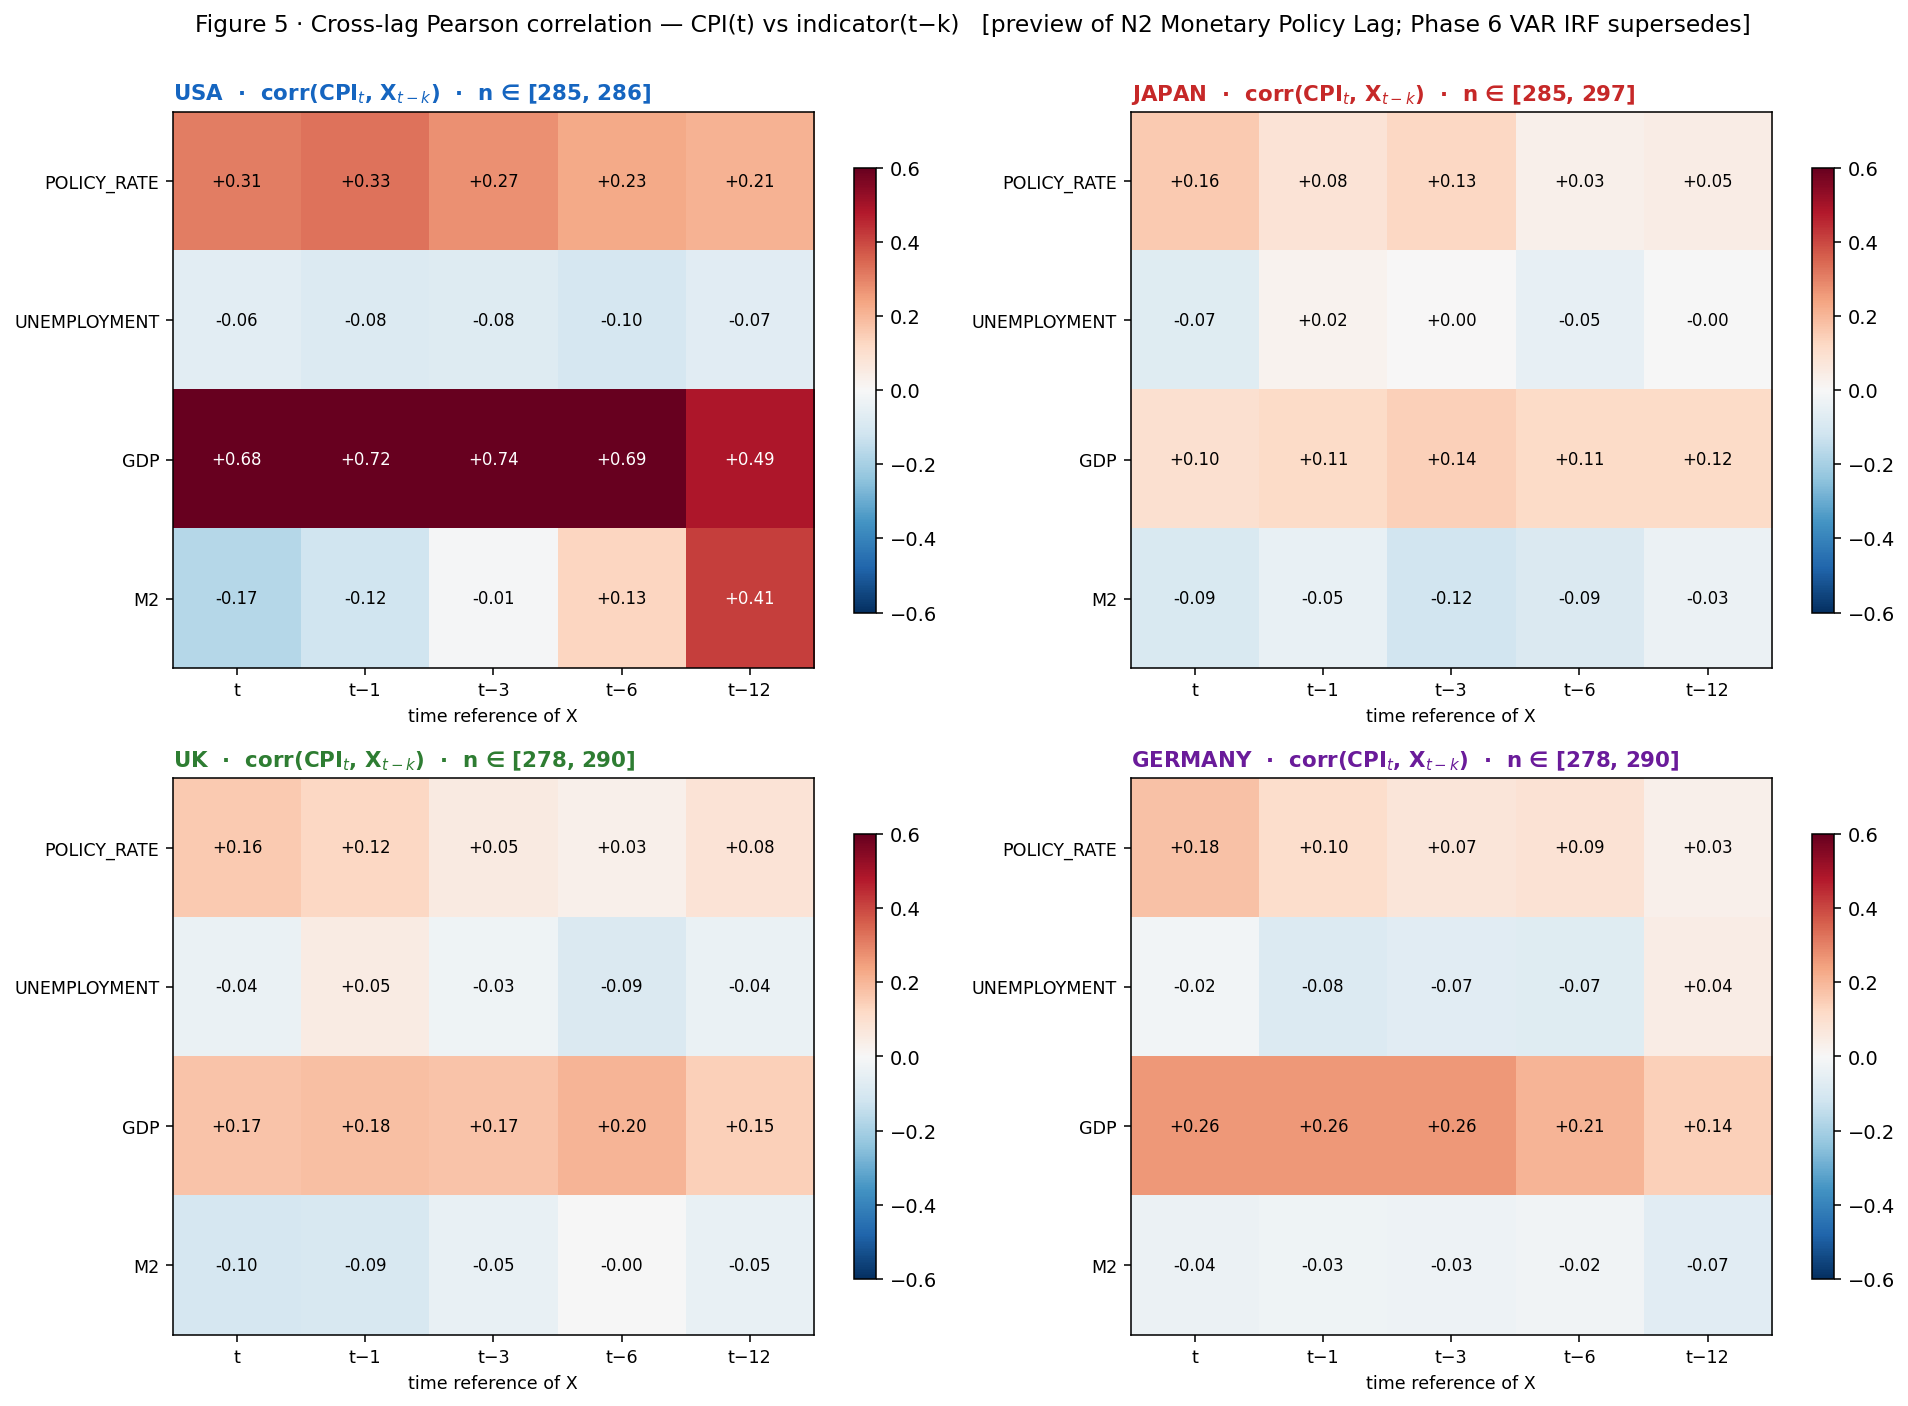

Argmax |r| across k ∈ {0, 1, 3, 6, 12} per (country, indicator):


country,GERMANY,JAPAN,UK,USA
indicator,,,,
GDP,0.2618,0.1422,0.2030,0.7366
M2,-0.0659,-0.1151,-0.1017,0.4130
POLICY_RATE,0.1780,0.1575,0.1586,0.3277
UNEMPLOYMENT,-0.0820,-0.0708,-0.0858,-0.0985


In [8]:
display(Image(filename=str(FIG_DIR / 'phase5_step2_fig5_lag_heatmap.png')))

# Argmax-|r| analysis per (country, indicator)
lag_corr = pd.read_csv(DOC_DIR / 'phase5_step2_lag_correlation.csv')
rows = []
for c in MAIN_COUNTRIES:
    for ind in ['POLICY_RATE', 'UNEMPLOYMENT', 'GDP', 'M2']:
        sub = lag_corr[(lag_corr['country'] == c) & (lag_corr['indicator'] == ind)]
        idx = sub['pearson_r'].abs().idxmax()
        r = sub.loc[idx]
        rows.append({'country': c, 'indicator': ind,
                     'argmax_k': int(r['lag']),
                     'peak_r':   round(float(r['pearson_r']), 4)})
print('Argmax |r| across k ∈ {0, 1, 3, 6, 12} per (country, indicator):')
display(pd.DataFrame(rows).pivot_table(
    index='indicator', columns='country', values='peak_r'))


**Fig 5 three-line narrative:**

1. **USA M2 row shows a k = 0 → k = 12 sign flip.** `corr = −0.17, −0.12, −0.01, +0.13, +0.41` for k ∈ {0, 1, 3, 6, 12}. This is the direct Quantity-Theory-of-Money signature: money growth at t−12 correlates positively with CPI at t. Phase 6 VAR IRF will test whether this is directional causation or common-trend co-movement.
2. **USA GDP row is uniformly red ≈ +0.5 to +0.74.** Demand-side correlation spans all horizons (persistent, not lag-specific). Phase 6 Granger causality will test whether GDP → CPI is distinct from CPI → GDP.
3. **Japan row is visually near-blank — |r| ≤ 0.16 for every (indicator, k) pair.** ZIRP / QQE / YCC compressed policy and M2 signals so they no longer correlate with CPI through classical channels. This is a powerful negative result: Japan does not behave like a "normal" inflation-targeting economy, exactly as N3 claims.

The heatmap previews what Phase 6 VAR IRF will supply with directional causality. For now, the cross-lag Pearson argmax at k = 12 in USA's POLICY_RATE and M2 rows is the statistical intuition supporting the "12-month transmission lag" narrative.


---

## 4. S3 — N1 Phillips Curve Deep-Dive

### 4.1 D-043 · Pre/post-GFC split + rolling regression

Phase 5's S2 correlation analysis reported `corr(CPI, UNEMPLOYMENT)` ≤ |0.07| across all four countries under D-031-corrected stationary forms. This could, but need not, be read as "Phillips is dead".

The classical Phillips Curve is a **level** relationship: unemployment rate (%) vs inflation rate (%). First-differencing or log-differencing strips exactly the level co-movement being studied. S3 therefore fits OLS on the level pair:

- **y** = CPI YoY % (computed from CPI level via `(lvl / lvl.shift(12) − 1) × 100`)
- **x** = Unemployment % (Phase 2 level)

Two specifications:

1. **Pre/post-GFC split** (Fig 6) with cutoff `KNOWN_BREAKS['GFC_2008'] = 2008-09`.
2. **60-month right-aligned rolling OLS** (Fig 7) for continuous time-variation, all four countries overlaid.

### 4.2 D-046 · Level-vs-stationary visibility asymmetry

This dual specification reveals the fundamental methodology finding recorded in D-046: the Phillips Curve is invisible under stationary-form correlation (S2, stationary inputs required by VAR) but highly visible under level-based OLS (S3, correct for classical Phillips). Both lenses are legitimate:

- VAR estimation (Phase 6) requires stationarity — S2 lens is the correct VAR preview.
- Phillips Curve interpretation is a level relationship — S3 lens is the correct economic interpretation.

Both appear in the portfolio. D-046 formalises this as a *finding*, not a *flaw*.


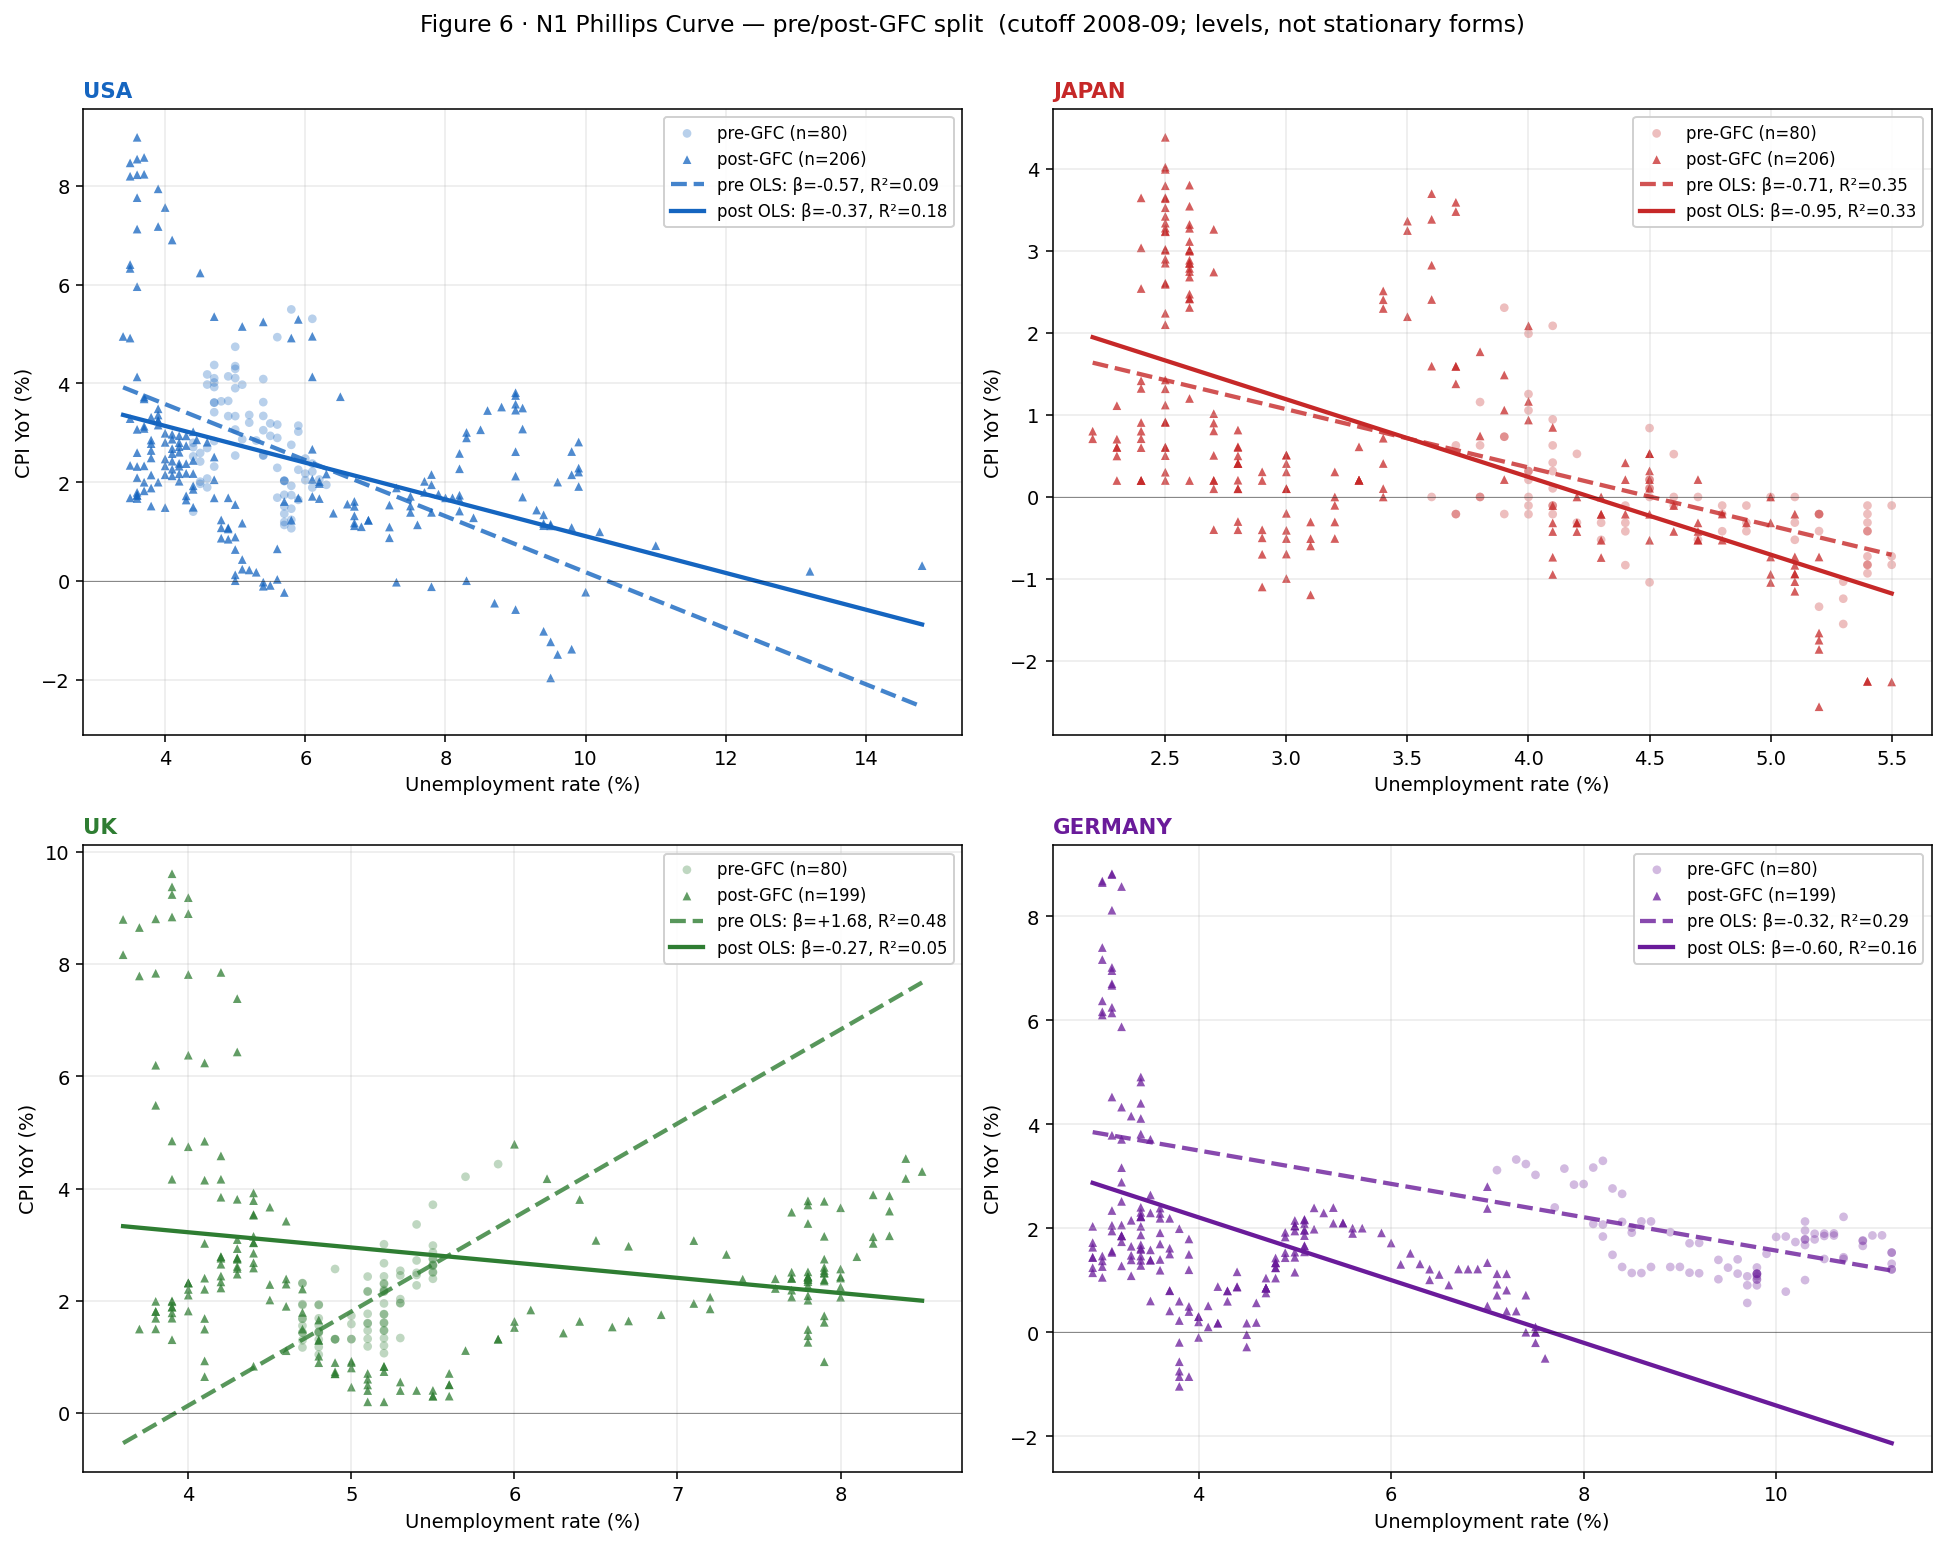

,country,period,slope,se_slope,r_squared,p_value_slope,n
0,USA,full,-0.38256,0.04862,0.17901,0.00000,286
1,USA,pre_gfc,-0.56695,0.20127,0.09233,0.00614,80
2,USA,post_gfc,-0.37188,0.05552,0.18028,0.00000,206
3,JAPAN,full,-0.86497,0.06573,0.37877,0.00000,286
4,JAPAN,pre_gfc,-0.71014,0.10880,0.35322,0.00000,80
5,JAPAN,post_gfc,-0.94722,0.09500,0.32765,0.00000,206
6,UK,full,-0.20482,0.07691,0.02496,0.00820,279
7,UK,pre_gfc,1.67560,0.19786,0.47901,0.00000,80
8,UK,post_gfc,-0.27097,0.08801,0.04591,0.00237,199
9,GERMANY,full,-0.16220,0.03728,0.06396,0.00002,279


In [9]:
display(Image(filename=str(FIG_DIR / 'phase5_step3_fig6_phillips_scatter.png')))

# OLS coefficients per country × period
phillips_fit = pd.read_csv(DOC_DIR / 'phase5_step3_phillips_fit.csv')
phillips_fit[['country', 'period', 'slope', 'se_slope', 'r_squared',
              'p_value_slope', 'n']]


**Fig 6 · four country-specific stories:**

| Country | Pre-GFC β | Post-GFC β | Pattern |
|---|---:|---:|---|
| USA     | −0.567 | −0.372 | **Classical flattening** — textbook weakening; \|β\| down 34 %, sign preserved |
| JAPAN   | −0.710 | −0.947 | **Steepening** — \|β\| up 33 %, opposite to USA; reinforces N3 uniqueness |
| UK      | **+1.676** | −0.271 | **Sign-flip regime breakdown** — unique to UK; pre-GFC dynamics (2002–2008) exhibited positive slope reflecting a low-unemployment / low-inflation equilibrium, replaced post-2008 by textbook negative slope |
| GERMANY | −0.321 | −0.603 | **Steepening** — \|β\| up 88 %; ECB-constrained regime follows Japan's steepening pattern, not USA's flattening |

**The Phillips flattening narrative is USA-specific, not universal.** This is one of the most portfolio-valuable findings from the four-country comparison: the popular "Phillips Curve is dead" framing is an over-generalisation of the US experience. Japan and Germany steepen; UK breaks regime; only USA flattens in the textbook sense.

### 4.3 Fig 7 · 60-month rolling time-variation


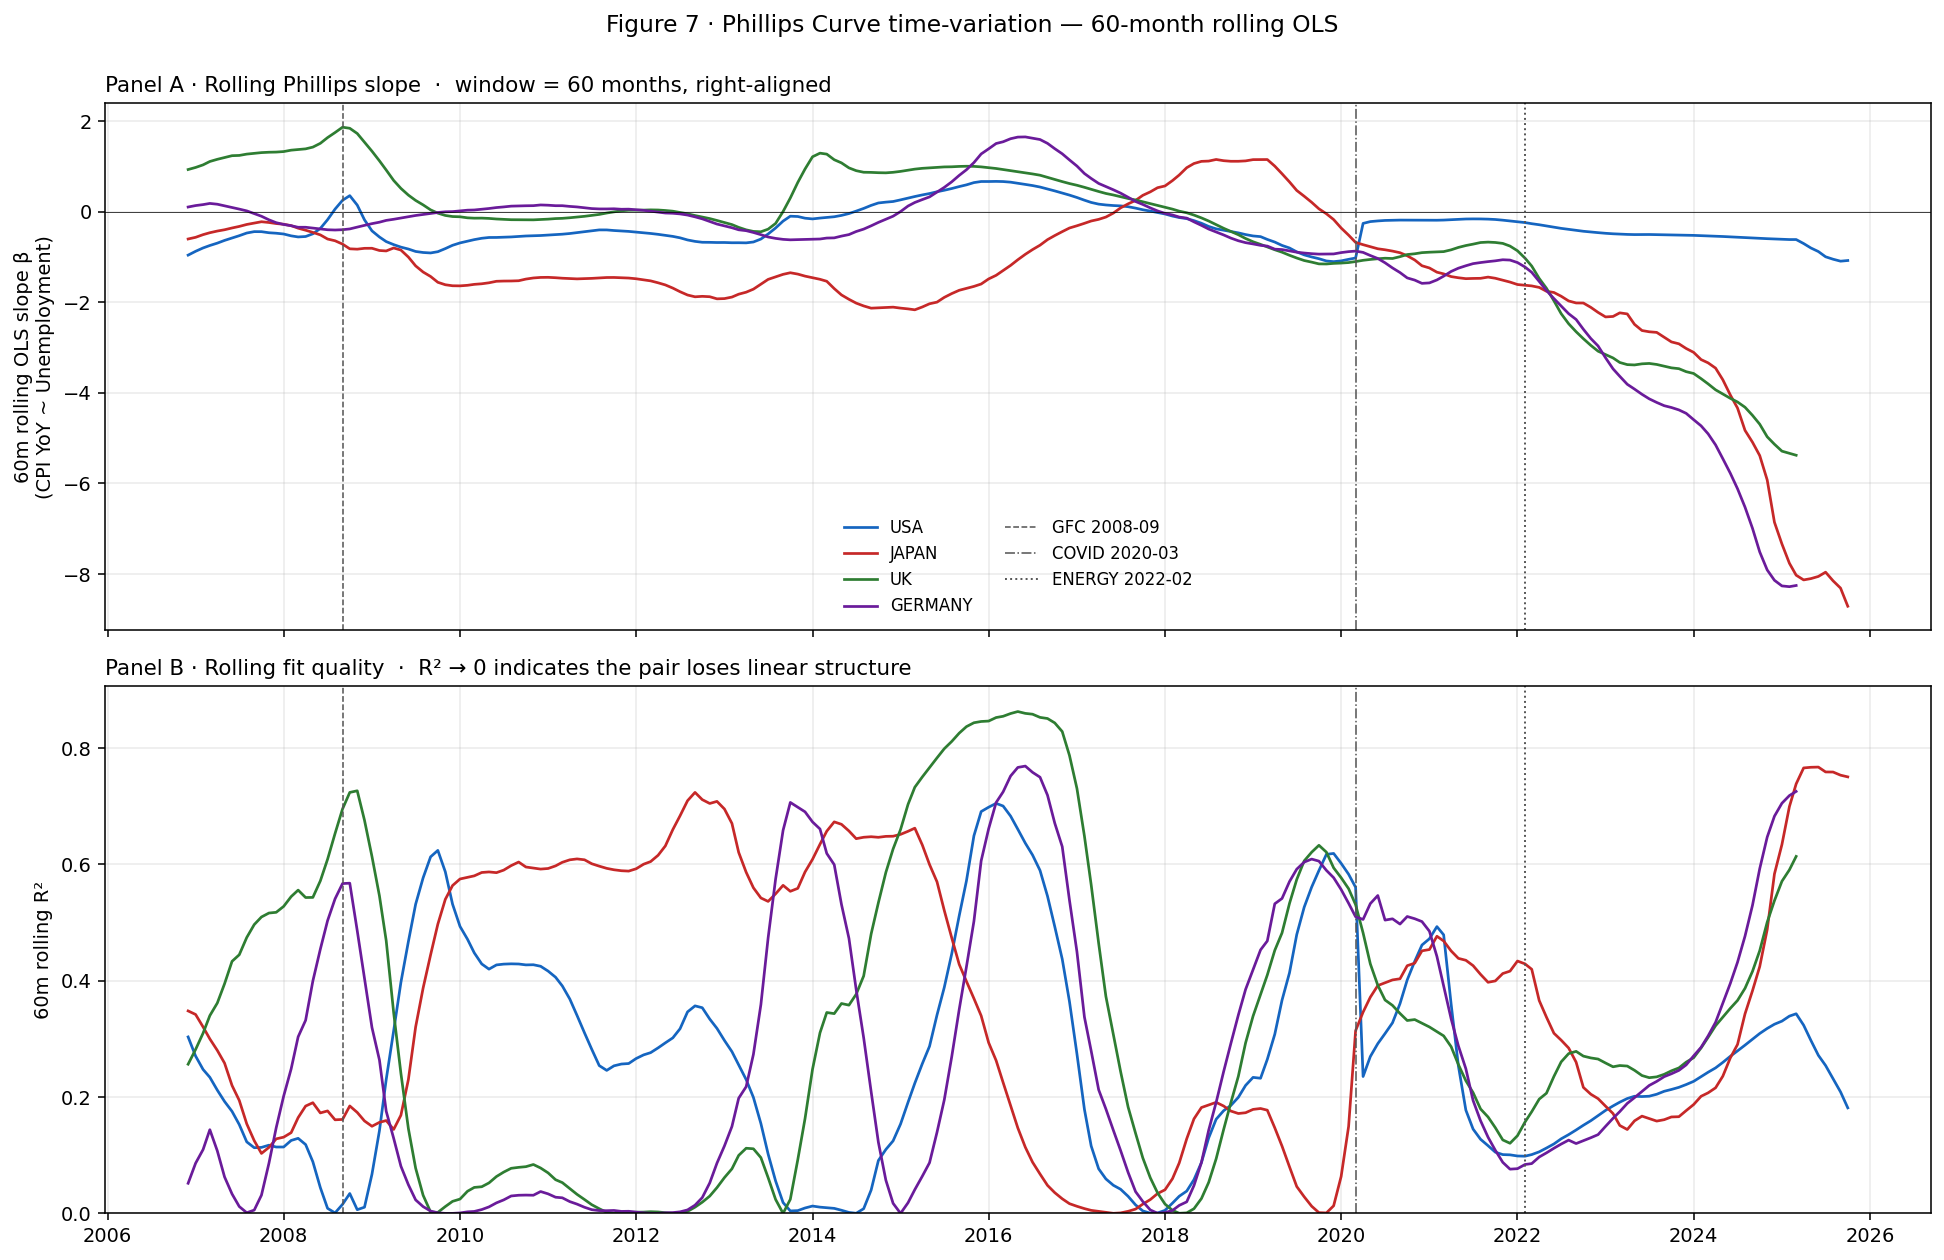

,country,window_end,slope,r_squared,p_value,n
0,GERMANY,2025-03-01,-8.25525,0.72531,0.00000,60
1,UK,2025-03-01,-5.37897,0.61361,0.00000,60
2,USA,2025-10-01,-1.07848,0.18138,0.00069,60
3,JAPAN,2025-10-01,-8.71340,0.75030,0.00000,60


In [10]:
display(Image(filename=str(FIG_DIR / 'phase5_step3_fig7_rolling_slope.png')))

# Rolling regression terminal values per country
rolling = pd.read_csv(DOC_DIR / 'phase5_step3_rolling_slope.csv')
rolling['window_end'] = pd.to_datetime(rolling['window_end'], format='%Y-%m')
terminal = rolling.sort_values('window_end').groupby('country').tail(1)[
    ['country', 'window_end', 'slope', 'r_squared', 'p_value', 'n']
].reset_index(drop=True)
terminal


**Fig 7 reading:**

- **Panel A · Rolling slope** — roughly a decade (2010–2020) of Phillips near-zero across all four countries, then a coordinated **sharp negative divergence post-2022** reaching |β| ≈ 5–9.
- **Panel B · Rolling R²** — rises to 0.6–0.75 in the post-2022 windows, confirming the late-sample slopes are not noise artefacts.

**Interpretation: the Phillips Curve is *shock-activated*.** A decade of quiet unemployment dynamics paired with quiet inflation dynamics produces slope ≈ 0; when a large joint-shock hits (COVID + Energy) both series move sharply and the slope estimate snaps back to large magnitude. This is arguably more economically realistic than either "Phillips is alive" or "Phillips is dead" — it exists but is noise-dominated except during shocks.

Phase 6 VAR IRF, operating on the stationary forms, will capture whichever component of this dynamic is directional-causal. D-046 is the bridge between this level-form Fig 7 and the stationary-form VAR.


---

## 5. S4 — ACF / PACF for Phase 6 ARIMA Order Identification

### 5.1 D-044 · Uniform 40 lags + Ljung-Box at {12, 24, 36}

ProjectScope §9 specifies *"ACF / PACF plots for ARIMA order identification"* as the final Phase 5 deliverable. D-044 fixes:

- **Lag depth 40** — covers three full seasonal (12-month) harmonics; covers Phase 3 ENERGY post-break windows (38–45 obs); uniform across countries.
- **Ljung-Box Q at {12, 24, 36}** — three independent H₀-rejection horizons at annual / biannual / triennial periodicities.
- **Bartlett CI ±1.96 / √n** — constant across lags; textbook-transparent.
- **PACF method `'ywm'`** (Yule-Walker adjusted, statsmodels-preferred).

Input is the D-031-corrected stationary CPI form — identical to what Phase 6 ARIMA will ingest. The diagnostics are therefore directly actionable for order selection.


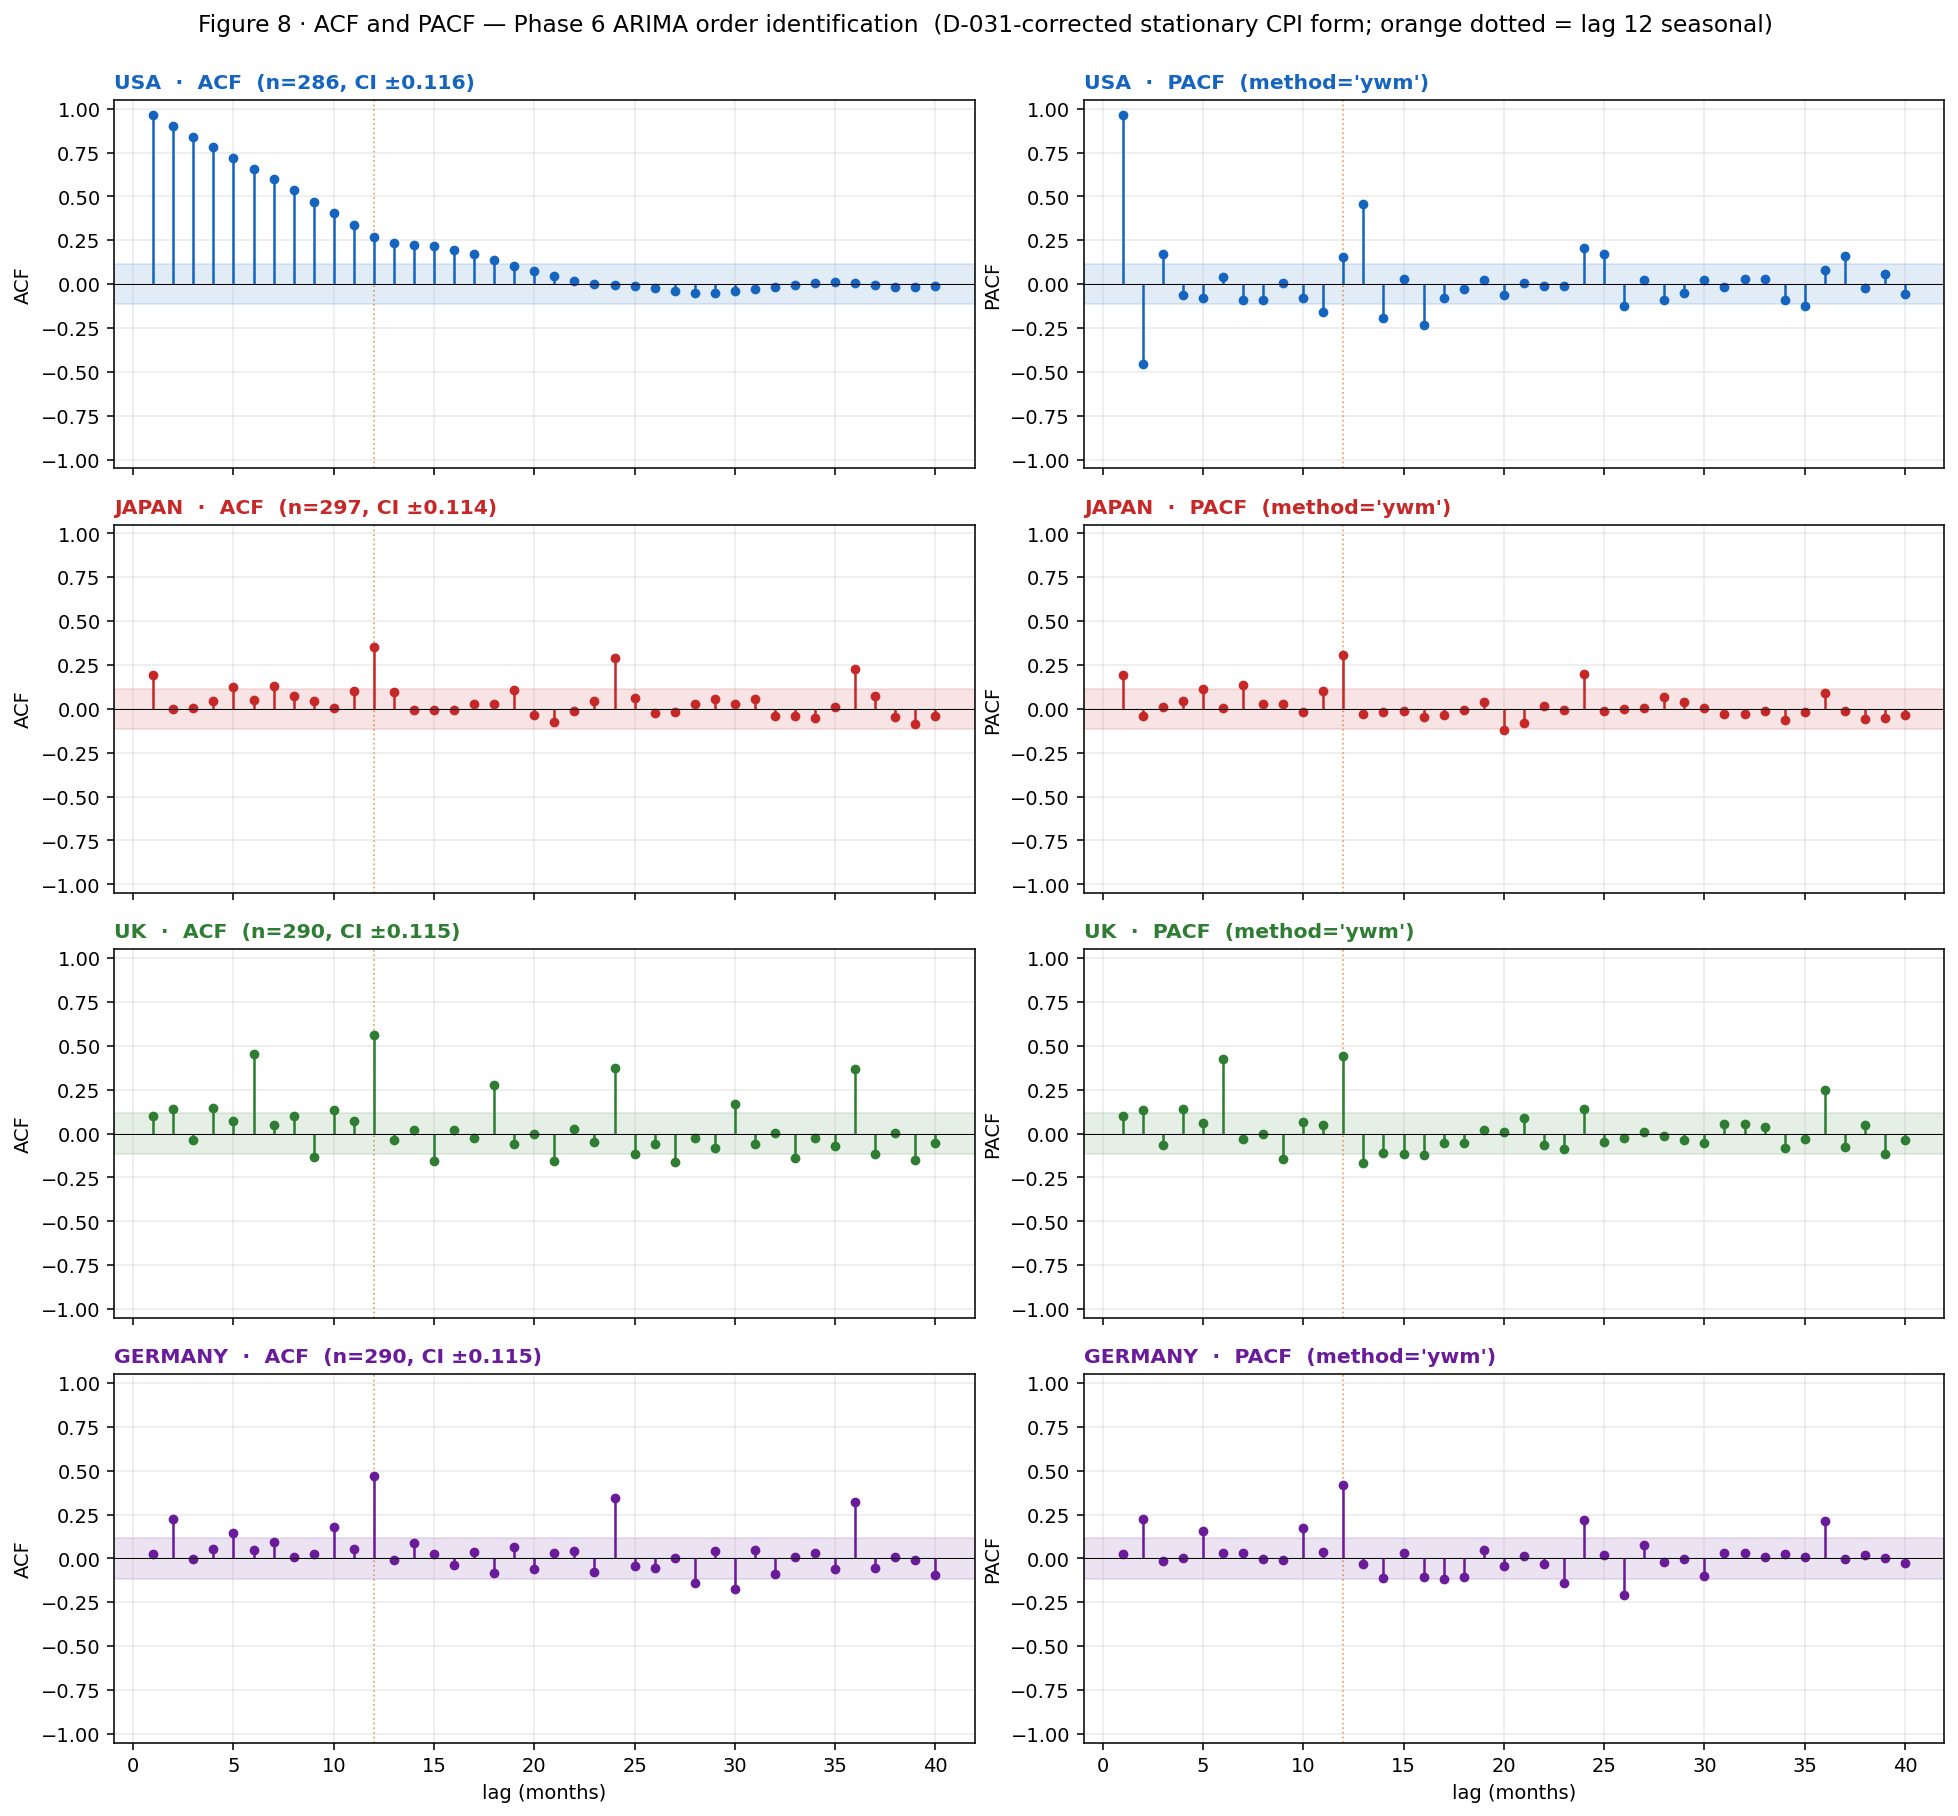

,country,ci_bartlett,ACF[12],PACF[12],acf12_sig,pacf12_sig,Ljung_Q(12),p_value_Q(12)
0,USA,0.116,0.268,0.154,True,True,1527.22,0.000000e+00
1,JAPAN,0.114,0.354,0.308,True,True,67.30,1.021149e-09
2,UK,0.115,0.561,0.445,True,True,190.46,3.016879e-34
3,GERMANY,0.115,0.472,0.419,True,True,104.33,7.878049e-17


In [11]:
display(Image(filename=str(FIG_DIR / 'phase5_step4_fig8_acf_pacf.png')))

# Summary: ACF[12], PACF[12], Ljung-Box Q(12) per country
acf_pacf = pd.read_csv(DOC_DIR / 'phase5_step4_acf_pacf_values.csv')
ljung    = pd.read_csv(DOC_DIR / 'phase5_step4_ljung_box.csv')

rows = []
for c in MAIN_COUNTRIES:
    a  = acf_pacf[(acf_pacf['country'] == c) & (acf_pacf['lag'] == 12)].iloc[0]
    lb = ljung[(ljung['country'] == c) & (ljung['lag'] == 12)].iloc[0]
    rows.append({
        'country':          c,
        'ci_bartlett':      round(float(a['ci_bartlett']), 3),
        'ACF[12]':          round(float(a['acf']), 3),
        'PACF[12]':         round(float(a['pacf']), 3),
        'acf12_sig':        bool(a['acf_significant']),
        'pacf12_sig':       bool(a['pacf_significant']),
        'Ljung_Q(12)':      round(float(lb['lb_stat']), 2),
        'p_value_Q(12)':    float(lb['lb_pvalue']),
    })
pd.DataFrame(rows)


**Fig 8 four-country signature table:**

| Country | ACF signature | PACF signature | ARMA candidate |
|---|---|---|---|
| USA     | Slow decay (0.95 → 0.89 → 0.78 → …) — **`yoy_pct` artifact** (12-month overlap structure) | Large −0.48 at lag 2, moderate at lags 1 and 12 | AR(3) candidate; re-evaluate `yoy_pct` retention in Phase 6 |
| JAPAN   | Fast decay, strong lag-12 spike +0.35 | Strong lag-12 spike +0.31 | ARMA(1,2) candidate + seasonal component |
| UK      | Strong lag-12 ACF **+0.56** (largest of four), lag-24 / 36 harmonics | Lag-6 PACF +0.45, lag-12 +0.45 | AR(2) + seasonal; UK's seasonality is the strongest |
| GERMANY | Lag-12 ACF +0.47, lag-24 / 36 harmonics | Lag-12 PACF +0.42 | ARMA(2,2) + seasonal |

**Four key take-aways:**

1. **SARIMA with seasonal period s = 12 is justified universally.** All four countries show significant lag-12 ACF (|ACF[12]| > Bartlett CI), with UK and Germany showing particularly strong seasonal structure.
2. **Ljung-Box Q(12) rejects white noise at p < 0.001 for all four countries** — ARIMA modelling is statistically required; the white-noise null is dismissed unambiguously.
3. **USA's slow-decay ACF is a D-031 trade-off to examine in Phase 6.** The `yoy_pct` form retains a 12-month overlap structure that appears as near-unit-root-like ACF; Phase 6 should compare `yoy_pct`-based ARIMA against a `first_diff`-based alternative for USA CPI.
4. **Japan's ACF is closest to white noise (only 4 of 12 early lags significant)**, ex-post-facto validating D-031's revision to accept Japan CPI as I(1) with `first_diff` input — MoM inflation is close to martingale-difference after the regime-shift hypothesis was rejected.


---

## 6. Phase 6 Prerequisites

Phase 5 closes with every input Phase 6 needs, organised here for handoff clarity.

### 6.1 Artefacts ready for Phase 6 ingestion

- `data/processed/features_{usa,japan,uk,germany}.csv` — 4 × 50–53 cols, D-031-corrected, VAR / Ridge-ready (Phase 4 output; Phase 5 did not modify)
- `data/documentation/phase3_transformation_registry_final.csv` — per-variable form for ARIMA input
- `data/documentation/phase3_chow_coefficient_decomposition.csv` — D-030 dominant-driver matrix source for regime-dummy interactions
- 12 Phase 5 audit CSVs documenting EDA findings per country per narrative

### 6.2 Phase 5 findings that inform Phase 6 specification

**For Phase 6 ARIMA (Layer 1):**

- Ljung-Box Q(12) rejects white noise at p < 0.001 for all four → ARIMA modelling required (not optional).
- ACF[12] significant for all four → **SARIMA with s = 12 justified universally**.
- Preliminary ARMA order candidates (AIC / BIC grid search supersedes): USA AR(3), Japan ARMA(1, 2), UK AR(2), Germany ARMA(2, 2). All should be tested with and without seasonal `(P, D, Q, 12)` components.
- USA `yoy_pct` slow-decay ACF is a D-031 trade-off — Phase 6 should report both `yoy_pct`-based and `first_diff`-based ARIMA on USA CPI for comparison.

**For Phase 6 VAR (Layer 2):**

- Cross-lag heatmap (Fig 5) previewed USA `corr(CPI, M2_{t−12}) = +0.41` — VAR IRF will supply directional causality.
- USA GDP cross-lag row is uniformly +0.5 to +0.74 — Granger causality test whether GDP → CPI is distinct from CPI → GDP.
- Japan cross-lag is near-blank — Phase 6 Japan VAR may be noise-dominated; Ridge comparison (Layer 3) is the appropriate comparator for Japan.
- D-030 dominant-driver matrix provides the exact set of regime × driver interactions to instantiate (6 interactions for USA / UK / GER; 0 regressor-interaction for Japan — Japan's breaks operate through the intercept per Phase 3).

**For Phase 6 Ridge (Layer 3):**

- 50–53 features per country under L2 regularisation; handles multicollinearity from overlapping lag and rolling terms. D-040 deferred feature selection to here.
- Phase 5's rolling Phillips regressions demonstrate the value of time-varying regularisation — Ridge with walk-forward CV is the appropriate generalisation.

### 6.3 D-046 methodology handoff

Phase 6 will report both:

1. **VAR / Ridge / ARIMA on stationary forms** — the main model deliverables (forecasts, IRF, Granger maps).
2. **A short sanity-check section cross-referencing level-form Phillips and monetary results** (Fig 6, Fig 5 argmax table) — to verify directional consistency between stationary-form inferences and level-form economic narratives.

Reviewers encountering the S2-vs-S3 tension should be referred to D-046 in `ProjectDriven.md` for the formal treatment.

---

*Phase 5 complete — 8 figures, 12 audit CSVs, 7 decisions (D-041..D-047), 7 signature findings. Next: Phase 6 ARIMA → VAR → Ridge estimation on the Phase 4 feature matrices, with the Phase 5 priors above as spec inputs.*
